# Pathwise convergence of formula (31) — ex-3, **violin** variant

Same sweeps, same differences, same numbers as `ex-3_pathwise_formula31` — the only change is
the distributional mark: **boxplots → violins**. Nothing in the original notebook or in any
`.py` file is touched; this is a side-by-side alternative for judging which representation reads
better.

Formula (31), per factor $j$:

$$\underbrace{\frac{\ell^{(p,n)}}{\theta_j^{(p,n)}}}_{\text{Left}}
\;\longrightarrow\;
\underbrace{\frac{\delta^2}{n\lambda_j^{(n)}+\delta^2}}_{\text{Middle}}
\;\longleftarrow\;
\underbrace{\lVert\Pi^{\perp}h_j\rVert^2}_{\text{Argument of right}}$$

All three quantities are recorded per replicate, so the differences are taken **pathwise** and
only then aggregated into a distribution.

The sweeps are the ones ex-2 v2 already persisted (`nb_outputs/ex2v2_df_{p,n}.parquet`) — same
model, design, seed and experiment class as ex-3's own — and are re-run only if that cache is
missing or does not match the design.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the notebook quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment

# Sweeps (parquet) stay in the shared cache — ex-2 v2, ex-3 and this notebook all read them.
# Figures go to a folder of this notebook's own, so nothing collides with the boxplot runs.
DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = DATA_DIR / "ex-3_pathwise_formula31_violin"
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"figures  → {OUT_DIR}")
print(f"sweeps   → {DATA_DIR}")

# Same calibration/seed as ex-2c — canonical diagonal-Gram model (c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)

HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511

_ret_lab = rf"$\mathcal{{T}}_{{{HEAVY_TAIL['factor_return_sampler']['df']}}}$"
_idio_lab = rf"$\mathcal{{T}}_{{{HEAVY_TAIL['idio_return_sampler']['df']}}}$"
print("ready")

figures  → /Users/alex/Documents/Finance_Projects/factor_lab/nb_outputs/ex-3_pathwise_formula31_violin
sweeps   → /Users/alex/Documents/Finance_Projects/factor_lab/nb_outputs
ready


## The violin panel

One helper, defined here rather than in `fl_graphics`, so the boxplot figures stay exactly as
they are. It has the same signature as `fl_graphics._np_gap_box_panel`, so every grid builder
below is the ex-3 builder with a single call swapped.

Knobs worth playing with while comparing representations: `VIOLIN_CLIP` (tail trim on the KDE
body — `None` shows the full support, at the cost of the panel's y-scale) and `VIOLIN_INNER`
(`"box"`, `"quartiles"`, `"median"`, `None`).

In [2]:
# ── Violin panel: drop-in replacement for fl_graphics._np_gap_box_panel ───────
# Same call signature, same dashed-zero reference, same x handling — only the
# distributional mark changes (KDE body instead of an IQR box).
VIOLIN_CLIP = (0.005, 0.995)   # tail trim applied to the KDE body only; None = untrimmed
VIOLIN_INNER = "box"           # "box" | "quartiles" | "median" | None


def _np_gap_violin_panel(ax, gaps, x, cats, color, *, clip=VIOLIN_CLIP,
                         inner=VIOLIN_INNER, width=0.8, zero_line=True):
    """Draw one factor's per-rep distribution as a violin at each swept value.

    Signature matches ``fl_graphics._np_gap_box_panel(ax, gaps, x, cats, color)`` so the
    figure builders below are the boxplot versions with one call swapped.

    ``gaps`` is a list (one entry per swept value, in plot order) of per-replicate arrays;
    ``x`` the integer positions; ``cats`` the tick labels.

    Conventions:
      * body   — Gaussian-KDE of the replicate distribution, each violin normalized to the
                 same maximum width (matplotlib default), so shape is comparable across
                 positions but width carries no count information;
      * ``clip`` — quantiles the body is trimmed to before the KDE. Heavy-tailed replicates
                 otherwise stretch the panel by orders of magnitude and flatten every violin
                 to a spike; the boxplot version hid the same mass via ``showfliers=False``.
                 The inner summary is always computed on the **untrimmed** sample.
      * inner  — "box" (1.5·IQR whisker line, thick IQR bar, white median dot),
                 "quartiles" (dashed Q1/Q3, solid median), "median", or None.
    A degenerate position (constant or single replicate) is drawn as a flat dash.
    """
    if zero_line:
        ax.axhline(0, color="0.6", lw=0.8, ls="--", zorder=1)   # theory-matches reference
    bodies, positions = [], []
    for arr, xi in zip(gaps, x):
        a = np.asarray(arr, dtype=float)
        a = a[np.isfinite(a)]
        if a.size == 0:
            continue
        q1, med, q3 = np.quantile(a, [0.25, 0.5, 0.75])
        iqr = q3 - q1
        inside = a[(a >= q1 - 1.5 * iqr) & (a <= q3 + 1.5 * iqr)]
        lo, hi = (inside.min(), inside.max()) if inside.size else (med, med)

        body = a
        if clip is not None and a.size > 1:
            c_lo, c_hi = np.quantile(a, clip)
            body = a[(a >= c_lo) & (a <= c_hi)]
        if body.size >= 2 and np.ptp(body) > 0:
            bodies.append(body)
            positions.append(xi)
        else:
            ax.plot([xi - width / 2, xi + width / 2], [med, med],
                    color=color, lw=1.6, zorder=3)

        if inner == "box":
            ax.vlines(xi, lo, hi, color="0.25", lw=0.9, zorder=5)
            ax.vlines(xi, q1, q3, color="0.15", lw=4.0, zorder=6)
            ax.plot([xi], [med], marker="o", ms=3.0, mfc="white", mec="0.15",
                    mew=0.7, zorder=7)
        elif inner == "quartiles":
            for yv, lw_, ls_ in ((q1, 0.9, "--"), (med, 1.3, "-"), (q3, 0.9, "--")):
                ax.plot([xi - width / 2, xi + width / 2], [yv, yv],
                        color="0.15", lw=lw_, ls=ls_, zorder=6)
        elif inner == "median":
            ax.plot([xi - width / 2, xi + width / 2], [med, med],
                    color="black", lw=1.2, zorder=6)

    if bodies:
        parts = ax.violinplot(bodies, positions=positions, widths=width,
                              showextrema=False, showmedians=False)
        for b in parts["bodies"]:
            b.set_facecolor(color)
            b.set_edgecolor(color)
            b.set_alpha(0.45)
            b.set_linewidth(0.8)
            b.set_zorder(3)
    ax.set_xlim(x[0] - 0.5, x[-1] + 0.5)
    ax.set_xticks(x, cats, fontsize=8)


_VIOLIN_CAP = ("violin = KDE of the per-rep distribution (inner 99%), thick bar = IQR, "
               "thin bar = 1.5·IQR range, white dot = median")

print('violin panel ready')

violin panel ready


## Notebook-local Analysis / Experiment classes

Carried over verbatim from ex-3 (which carried them from ex-2c) — needed only for the fallback
path when the cached sweeps are absent.

In [3]:
import numpy as np
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment


class ObservableSpectrumAnalysis:
    """Observable side of Corollary 1: eigendecompose the n×n Gram G = Y^T Y, keep the full
    spectrum for the bulk average ℓ, and the top-k spikes θ_j (dual rescaled by 1/(n·p))."""

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        p, n = Y.shape
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        order = np.argsort(eigenvalues)[::-1]
        top_k = order[:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)   # (p, k)
        sin2_angle, dist_sine = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)

        dual = eigenvalues[order] / (n * p)
        theta = dual[:k]
        bulk = dual[k:n - 1] if self.center else dual[k:]
        ell = float(bulk.mean())
        return {"sin2_j": sin2_angle, "dist_sine": dist_sine,
                "sample_spike_eigenvalues_theta": theta,
                "sample_bulk_eigenvalue_average_ell": ell,
                "observable_floor_estimate": ell / theta}


class ObservableFloorExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [ObservableSpectrumAnalysis(b_pop, center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        gap = merged["sin2_j"] - merged["rhs"]
        return [
            {"n": n, "p": p, "j": j + 1,
             "sin2_j": float(merged["sin2_j"][j]), "rhs": float(merged["rhs"][j]),
             "gap": float(gap[j]), "floor": float(merged["floor"][j]),
             "rotation": float(merged["rotation"][j]), "rho": float(merged["rhos"][j]),
             "theta_j_sample_eigenvalue": float(merged["sample_spike_eigenvalues_theta"][j]),
             "ell_bulk_eigenvalue_average": float(merged["sample_bulk_eigenvalue_average_ell"]),
             "observable_floor_estimate": float(merged["observable_floor_estimate"][j])}
            for j in range(k)]


class MeasuredDecompositionAnalysis(ObservableSpectrumAnalysis):
    """Adds the finite-p eq.(18) split: ‖Π⊥h_j‖² via projection of h_j onto col(b_pop)."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        top_k = np.argsort(eigenvalues)[::-1][:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)
        coeffs = self.population_loading_directions_b_pop @ H           # (k, k)
        in_subspace = (coeffs ** 2).sum(axis=0)
        result["measured_out_of_subspace"] = 1.0 - in_subspace          # ‖Π⊥h_j‖²
        result["measured_in_subspace"] = result["sin2_j"] - (1.0 - in_subspace)
        return result


class MeasuredDecompositionExperiment(ObservableFloorExperiment):
    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [MeasuredDecompositionAnalysis(b_pop, center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        rows = super().record(n, p, merged)
        for j, row in enumerate(rows):
            row["measured_out_of_subspace"] = float(merged["measured_out_of_subspace"][j])
            row["measured_in_subspace"] = float(merged["measured_in_subspace"][j])
        return rows

print("measured-decomposition classes defined")

measured-decomposition classes defined


## The two sweeps

Growing $p$ at fixed $n=63$, and growing $n$ at fixed $p=3000$; $R=1000$ replicates, same seed
as ex-2c / ex-2 v2 / ex-3.

In [4]:
design_p = DesignSpec(
    n_values=[63],
    p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250],
    p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)


def load_or_run(path, design, label):
    """Reuse the cached sweep if it matches this design; else run and cache it. ex-2 v2 and ex-3
    run the identical model / design / seed / experiment class, so the frames are the same sweep."""
    if path.exists():
        d = pd.read_parquet(path)
        matches = (sorted(d["n"].unique()) == sorted(design.n_values)
                   and sorted(d["p"].unique()) == sorted(design.p_values)
                   and int(d.groupby(["n", "p", "j"]).size().max()) == design.n_reps)
        if matches:
            print(f"{label}: loaded cached sweep {path.name} ({len(d):,} rows)")
            return d
        print(f"{label}: cached {path.name} does not match the design — re-running")
    d = run_experiment(model, design, MeasuredDecompositionExperiment(), progress=True)
    d.to_parquet(path)
    print(f"{label}: ran sweep ({len(d):,} rows) and cached to {path.name}")
    return d


df_p = load_or_run(DATA_DIR / "ex2v2_df_p.parquet", design_p, "growing-p")
df_n = load_or_run(DATA_DIR / "ex2v2_df_n.parquet", design_n, "growing-n")
print(f"growing-p: {len(df_p)} rows, p ∈ {sorted(df_p['p'].unique())}, n=63, reps={N_REPS}")
print(f"growing-n: {len(df_n)} rows, n ∈ {sorted(df_n['n'].unique())}, p=3000, reps={N_REPS}")

growing-p: loaded cached sweep ex2v2_df_p.parquet (18,000 rows)
growing-n: loaded cached sweep ex2v2_df_n.parquet (27,000 rows)
growing-p: 18000 rows, p ∈ [np.int64(100), np.int64(500), np.int64(5000), np.int64(10000), np.int64(20000), np.int64(50000)], n=63, reps=1000
growing-n: 27000 rows, n ∈ [np.int64(20), np.int64(30), np.int64(45), np.int64(60), np.int64(63), np.int64(90), np.int64(120), np.int64(180), np.int64(250)], p=3000, reps=1000


In [5]:
# Sanity: eq. (18) holds exactly at every finite p — the measured split must
# reconstruct the measured total to machine precision, per replicate.
for name, df in (("growing-p", df_p), ("growing-n", df_n)):
    recon = df["measured_out_of_subspace"] + df["measured_in_subspace"]
    print(f"{name}: max |sin2_j − (oos + insub)| = {(df['sin2_j'] - recon).abs().max():.3e}")

growing-p: max |sin2_j − (oos + insub)| = 0.000e+00
growing-n: max |sin2_j − (oos + insub)| = 0.000e+00


## Figures 1–2 — band decomposition (existing view, new frames)

No per-replicate mark here, so these are the shared `fl_graphics.top_row_decomposition` figures
unchanged — included so the violin notebook stands on its own.

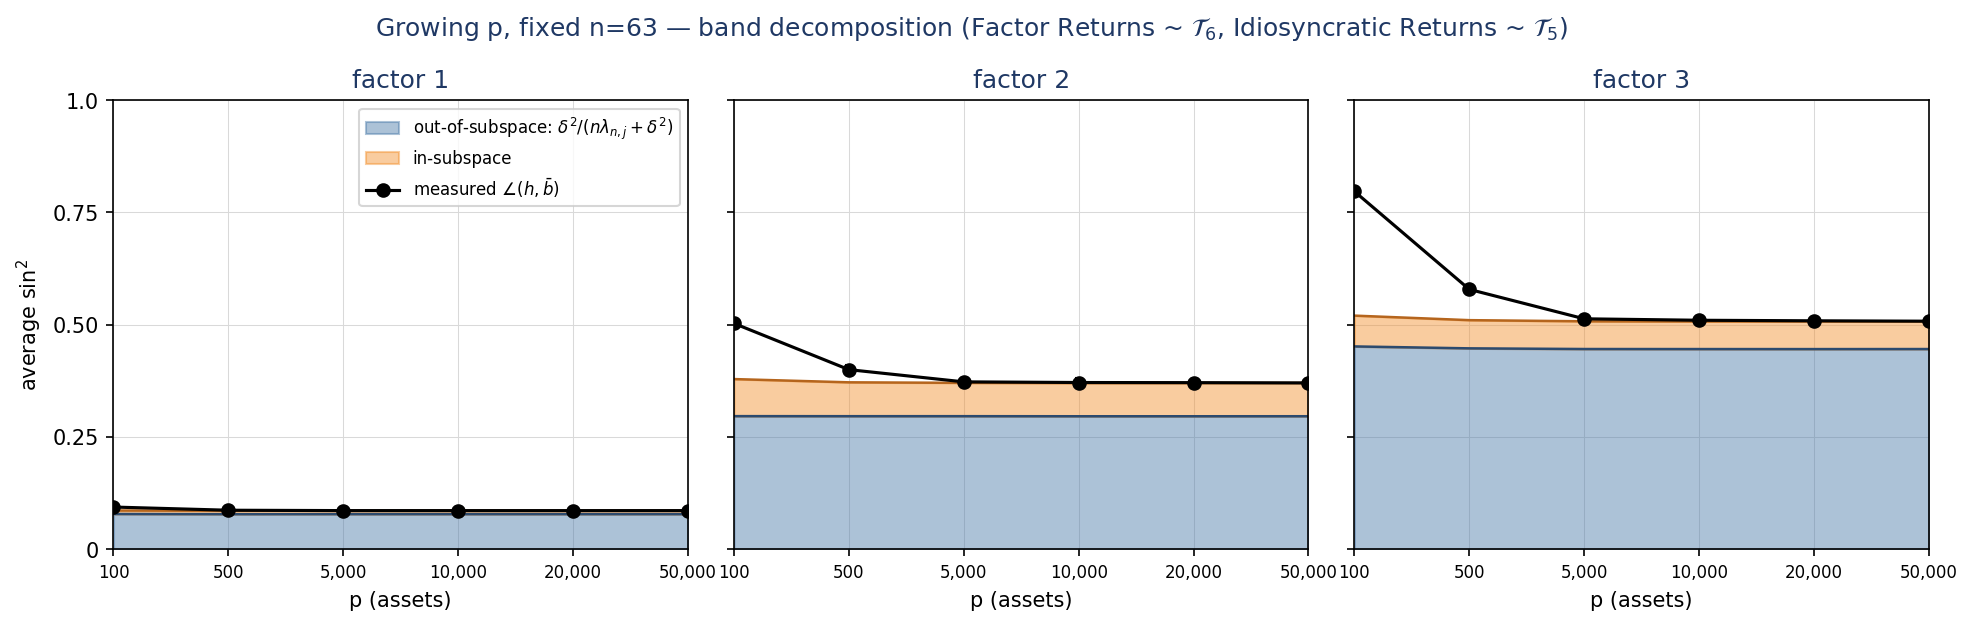

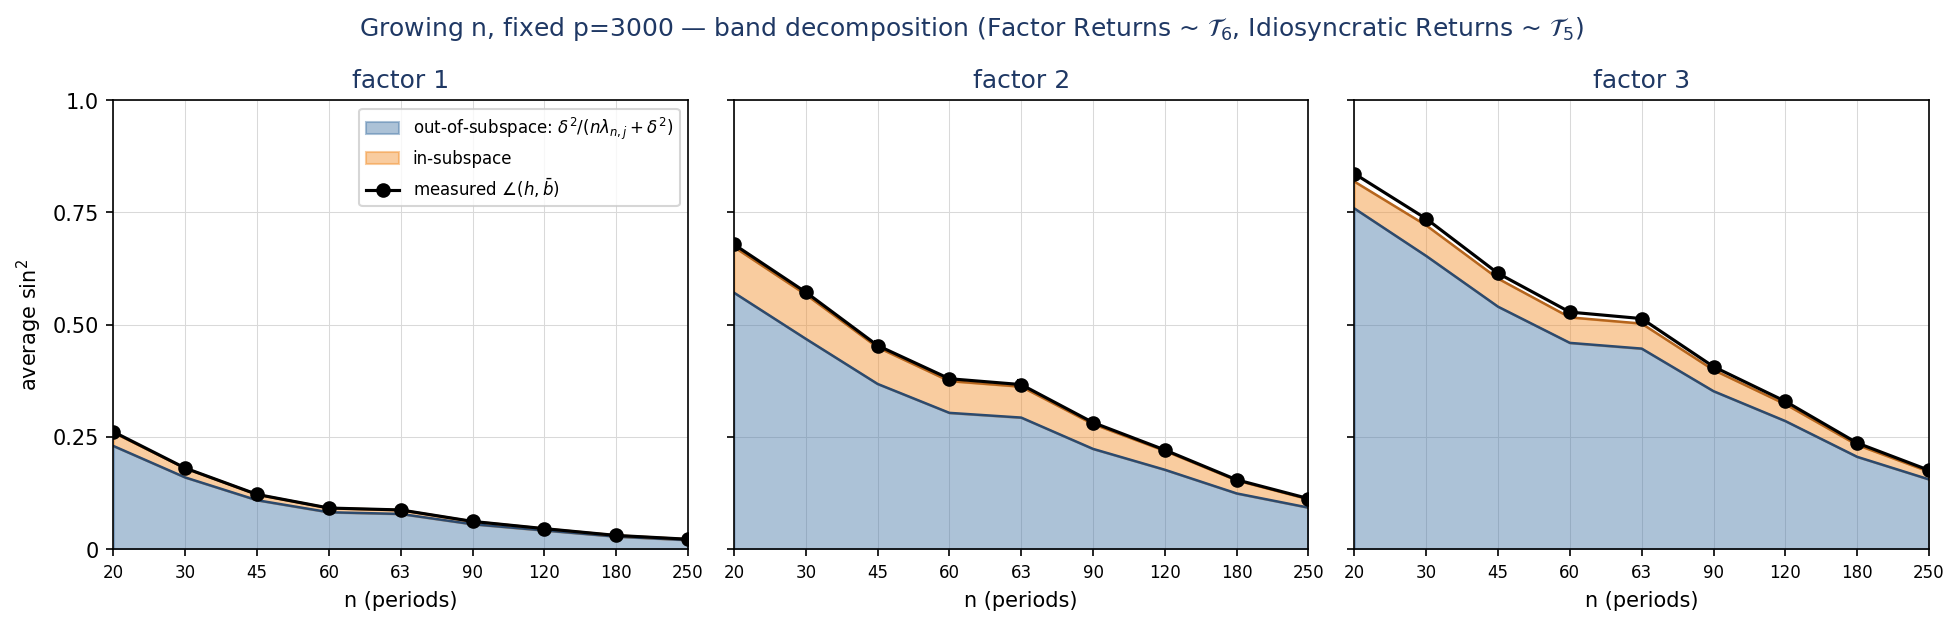

In [6]:
from fl_graphics import top_row_decomposition

_band_p_png = OUT_DIR / "ex3_violin_band_growing_p.png"
fig_band_p, _ = top_row_decomposition(
    df_p, key="p", out_path=str(_band_p_png),
    suptitle=rf"Growing p, fixed n=63 — band decomposition "
             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
display(Image(filename=str(_band_p_png)))
plt.close(fig_band_p)

_band_n_png = OUT_DIR / "ex3_violin_band_growing_n.png"
fig_band_n, _ = top_row_decomposition(
    df_n, key="n", out_path=str(_band_n_png),
    suptitle=rf"Growing n, fixed p=3000 — band decomposition "
             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
display(Image(filename=str(_band_n_png)))
plt.close(fig_band_n)

## Figures 3–4 — pathwise difference violins

Per-replicate differences computed first, then shown as violins (each replicate is an
independent sample of the difference). Rows, per the (31) labels:

1. **Left − Middle** — `observable_floor_estimate − floor`
2. **Argument of right − Left** — `measured_out_of_subspace − observable_floor_estimate`
3. **Middle − Argument of right** — `floor − measured_out_of_subspace`

Columns are factors 1–3. Violin convention: KDE body over the inner 99% of replicates, inner
1.5·IQR line + IQR bar + white median dot, dashed zero reference. Y-limits auto-scale per row;
the zero line is a reference, not an assumed center. One figure per sweep.

In [7]:
from fl_graphics import _NP_COLORS, _NP_NAVY

_DIFF_ROWS = [
    ("diff_left_middle", "Left − Middle",
     r"$\ell/\theta_j\; -\; \delta^2/(n\lambda_j^{(n)}+\delta^2)$"),
    ("diff_arg_left", "Argument of right − Left",
     r"$\Vert\Pi^{\perp}h_j\Vert^2\; -\; \ell/\theta_j$"),
    ("diff_middle_arg", "Middle − Argument of right",
     r"$\delta^2/(n\lambda_j^{(n)}+\delta^2)\; -\; \Vert\Pi^{\perp}h_j\Vert^2$"),
]

def add_pathwise_differences(df):
    """Per-replicate differences of the three formula-(31) components."""
    return df.assign(
        diff_left_middle=df["observable_floor_estimate"] - df["floor"],
        diff_arg_left=df["measured_out_of_subspace"] - df["observable_floor_estimate"],
        diff_middle_arg=df["floor"] - df["measured_out_of_subspace"],
    )

def pathwise_violin_grid(df, swept_key, *, suptitle=None, out_path=None):
    """3×3 grid: rows = the three pairwise differences, columns = factors.
    Each panel violins the per-replicate difference at each swept value — ex-3's
    pathwise_boxplot_grid with _np_gap_box_panel → _np_gap_violin_panel."""
    rf = add_pathwise_differences(df)
    factors = [1, 2, 3]
    order = sorted(rf[swept_key].unique())
    cats = [f"{v:,}" for v in order] if swept_key == "p" else [str(v) for v in order]
    x = np.arange(len(order))
    xlabel = "p (assets)" if swept_key == "p" else "n (periods)"

    fig, axes = plt.subplots(3, 3, figsize=(13.3, 9.6), sharex="col", sharey="row")
    fig.subplots_adjust(left=0.09, right=0.97, top=0.90, bottom=0.09,
                        hspace=0.14, wspace=0.08)
    for row, (col_name, row_label, row_math) in enumerate(_DIFF_ROWS):
        for col, j in enumerate(factors):
            ax = axes[row, col]
            sub = rf[rf["j"] == j]
            dists = [sub.loc[sub[swept_key] == v, col_name].to_numpy() for v in order]
            _np_gap_violin_panel(ax, dists, x, cats, _NP_COLORS[col])
            ax.set_axisbelow(True)
            ax.grid(True, color="0.85", lw=0.5)
            if row == 0:
                ax.set_title(f"factor {j}", color=_NP_NAVY)
            if row == 2:
                ax.set_xlabel(xlabel)
            else:
                ax.tick_params(labelbottom=False)
        axes[row, 0].set_ylabel(f"{row_label}\n{row_math}", fontsize=9)
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.985)
    fig.text(0.5, 0.015,
             f"per-replicate difference per swept value: {_VIOLIN_CAP}; "
             f"dashed 0 = components agree (R = {N_REPS}).",
             ha="center", fontsize=7, color="0.35")
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes

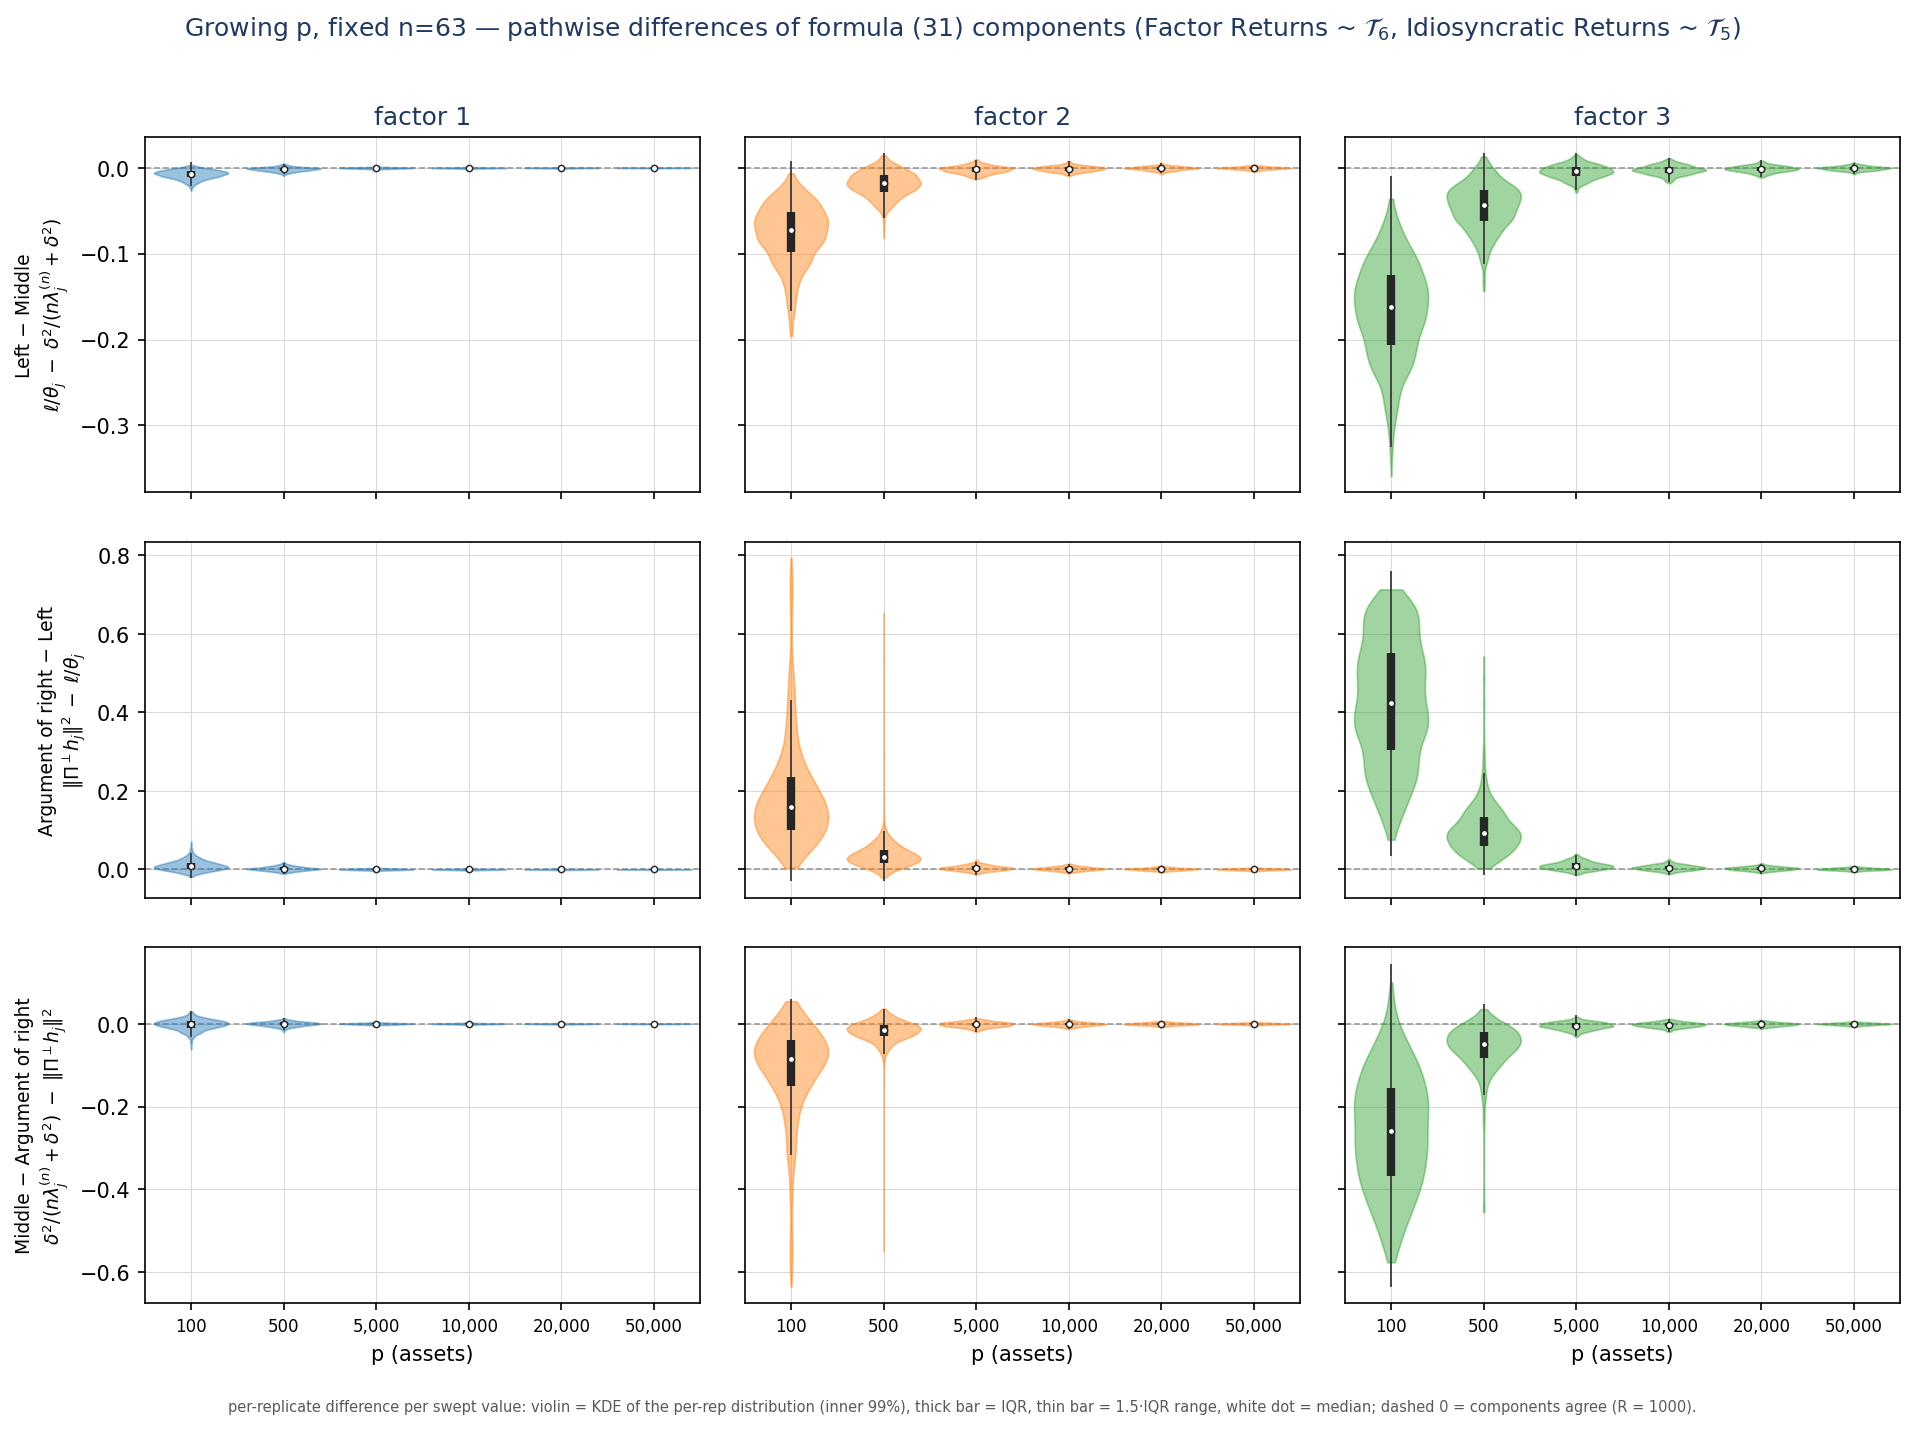

In [8]:
_v_p_png = OUT_DIR / "ex3_pathwise_violins_growing_p.png"
fig_v_p, _ = pathwise_violin_grid(
    df_p, "p", out_path=str(_v_p_png),
    suptitle=rf"Growing p, fixed n=63 — pathwise differences of formula (31) components "
             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
display(Image(filename=str(_v_p_png)))
plt.close(fig_v_p)

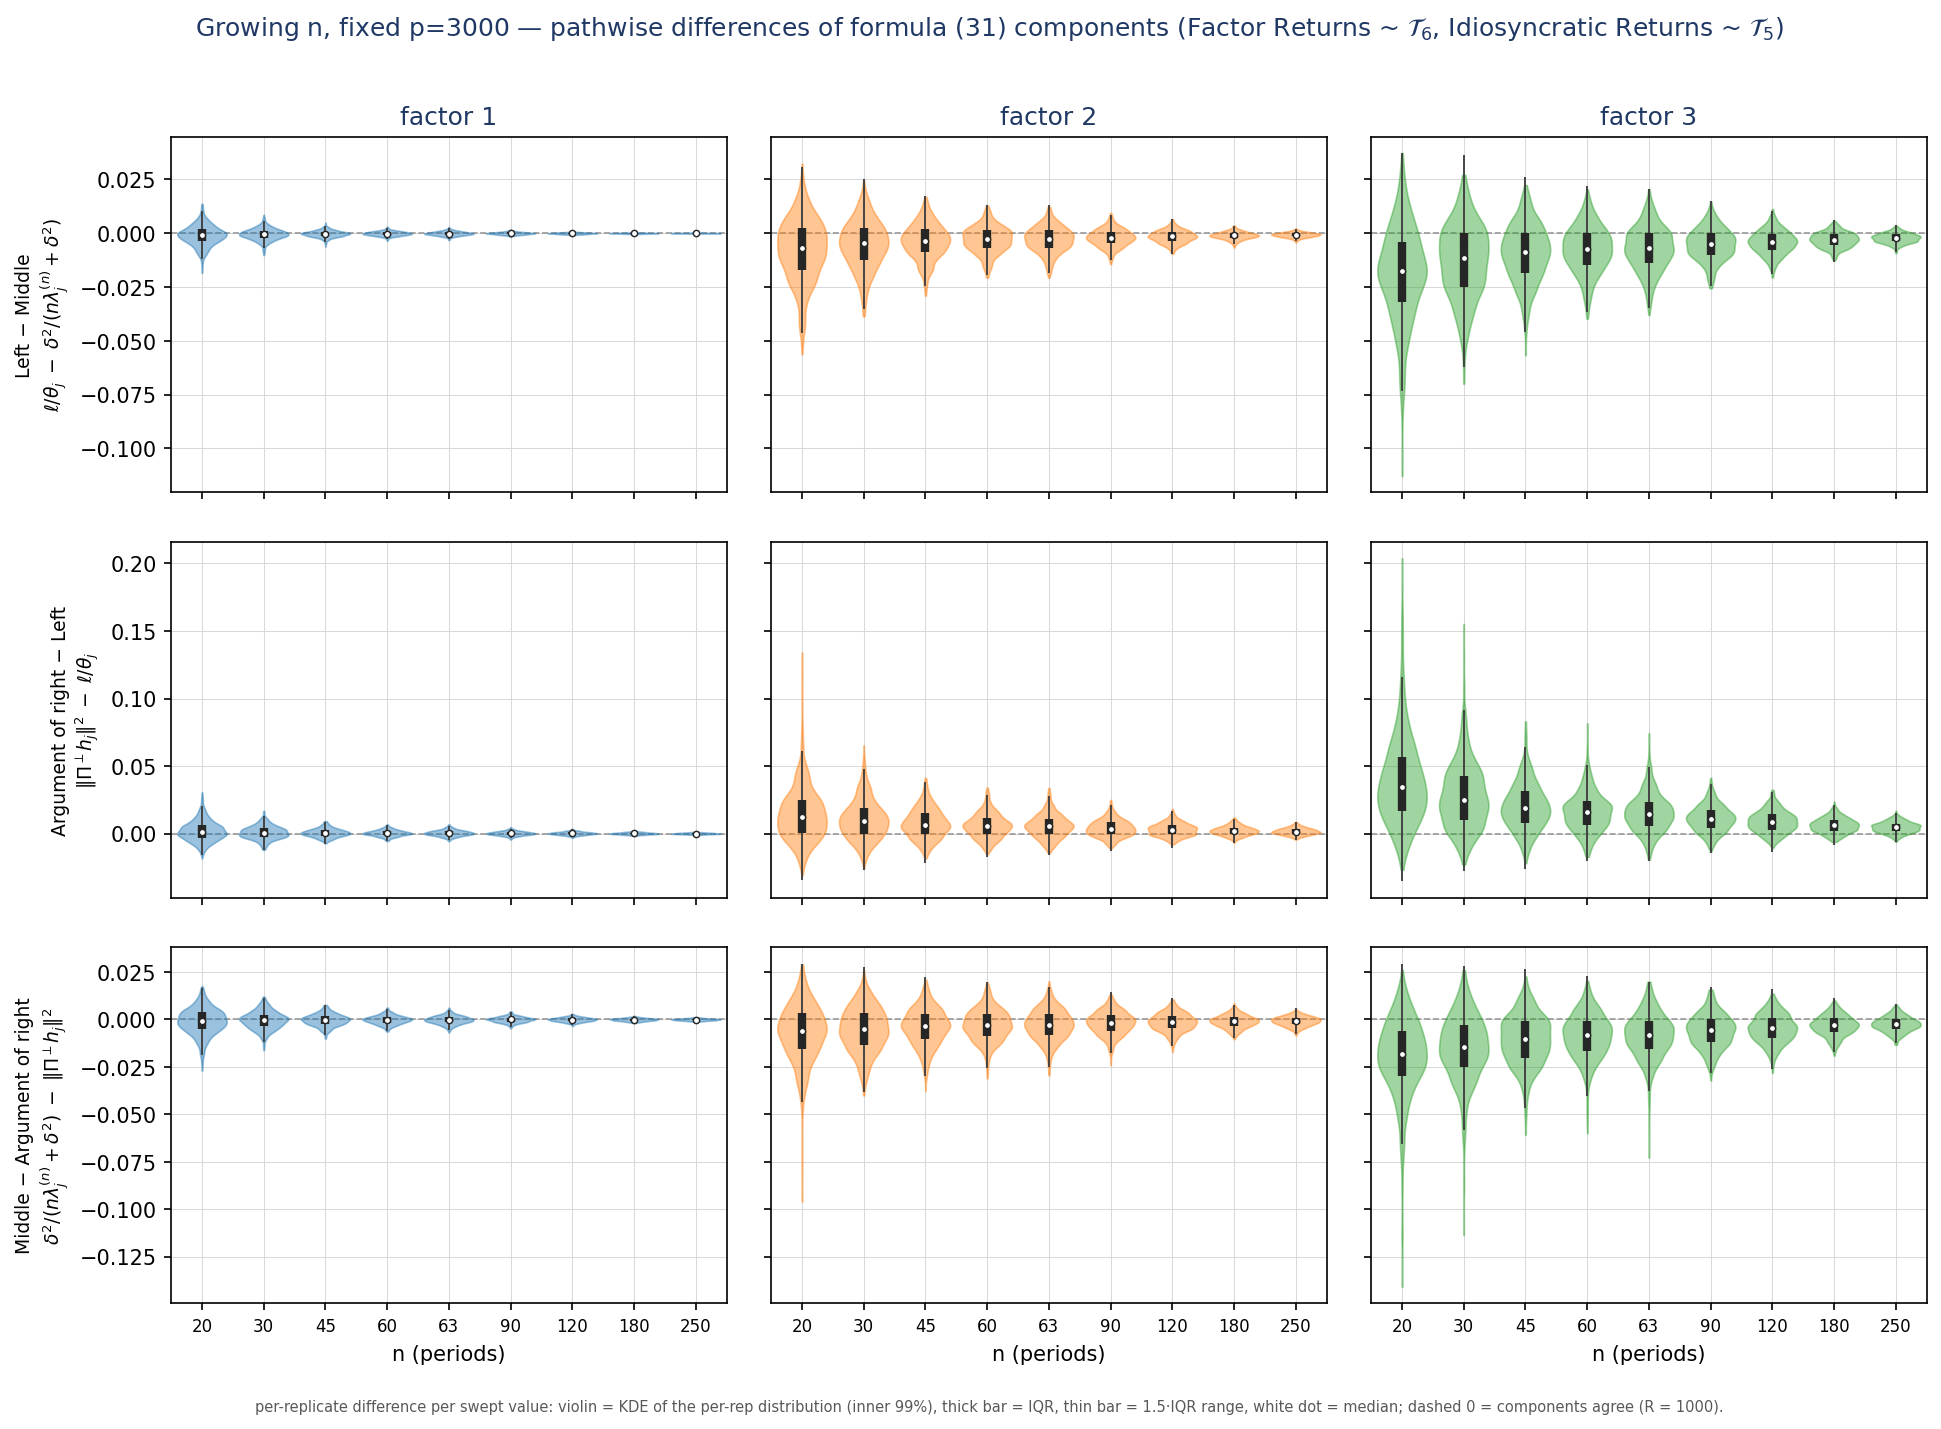

In [9]:
_v_n_png = OUT_DIR / "ex3_pathwise_violins_growing_n.png"
fig_v_n, _ = pathwise_violin_grid(
    df_n, "n", out_path=str(_v_n_png),
    suptitle=rf"Growing n, fixed p=3000 — pathwise differences of formula (31) components "
             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
display(Image(filename=str(_v_n_png)))
plt.close(fig_v_n)

## Numbers behind the violins

Median and IQR of each per-replicate difference, per (swept value, factor) — the same table as
ex-3, and the numeric anchor for each violin's inner bar. Pathwise convergence shows up as
medians → 0 with shrinking IQRs.

In [10]:
def pathwise_difference_table(df, swept_key):
    rf = add_pathwise_differences(df)
    rows = []
    for col_name, row_label, _ in _DIFF_ROWS:
        g = rf.groupby([swept_key, "j"])[col_name]
        t = g.agg(median="median",
                  q25=lambda s: s.quantile(0.25),
                  q75=lambda s: s.quantile(0.75)).reset_index()
        t.insert(0, "difference", row_label)
        rows.append(t)
    out = pd.concat(rows, ignore_index=True)
    out["IQR"] = out["q75"] - out["q25"]
    return out

tbl_p = pathwise_difference_table(df_p, "p")
tbl_n = pathwise_difference_table(df_n, "n")
print("Growing p (n=63):")
display(tbl_p.round(5))
print("Growing n (p=3000):")
display(tbl_n.round(5))

Growing p (n=63):


,difference,p,j,median,q25,q75,IQR
0,Left − Middle,100,1,-0.00700,-0.01079,-0.00387,0.00692
1,Left − Middle,100,2,-0.07208,-0.09816,-0.05122,0.04693
2,Left − Middle,100,3,-0.16244,-0.20632,-0.12505,0.08127
3,Left − Middle,500,1,-0.00135,-0.00312,0.00001,0.00313
4,Left − Middle,500,2,-0.01794,-0.02812,-0.00775,0.02037
5,Left − Middle,500,3,-0.04330,-0.06225,-0.02595,0.03631
6,Left − Middle,5000,1,-0.00015,-0.00062,0.00033,0.00095
7,Left − Middle,5000,2,-0.00171,-0.00490,0.00097,0.00587
8,Left − Middle,5000,3,-0.00420,-0.00967,0.00126,0.01093
9,Left − Middle,10000,1,-0.00008,-0.00040,0.00024,0.00064


Growing n (p=3000):


,difference,n,j,median,q25,q75,IQR
0,Left − Middle,20,1,-0.00086,-0.00376,0.00185,0.00561
1,Left − Middle,20,2,-0.00685,-0.01725,0.00229,0.01954
2,Left − Middle,20,3,-0.01768,-0.03192,-0.00407,0.02785
3,Left − Middle,30,1,-0.00052,-0.00213,0.00113,0.00326
4,Left − Middle,30,2,-0.00476,-0.01268,0.00239,0.01508
...,...,...,...,...,...,...,...
76,Middle − Argument of right,180,2,-0.00095,-0.00322,0.00119,0.00441
77,Middle − Argument of right,180,3,-0.00299,-0.00654,0.00064,0.00718
78,Middle − Argument of right,250,1,-0.00001,-0.00041,0.00033,0.00075
79,Middle − Argument of right,250,2,-0.00070,-0.00255,0.00095,0.00350


In [11]:
#### SAVE FIGURES (PNG 300 dpi + PDF)
for fig_fn, base in [
    (lambda: top_row_decomposition(df_p, key="p")[0], "ex3_violin_band_growing_p"),
    (lambda: top_row_decomposition(df_n, key="n")[0], "ex3_violin_band_growing_n"),
    (lambda: pathwise_violin_grid(df_p, "p")[0], "ex3_pathwise_violins_growing_p"),
    (lambda: pathwise_violin_grid(df_n, "n")[0], "ex3_pathwise_violins_growing_n"),
]:
    fig = fig_fn()
    fig.savefig(OUT_DIR / f"{base}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{base}.pdf", bbox_inches="tight")
    plt.close(fig)
print(f"saved 4 figures (png+pdf) to {OUT_DIR}")

saved 4 figures (png+pdf) to /Users/alex/Documents/Finance_Projects/factor_lab/nb_outputs/ex-3_pathwise_formula31_violin


## Figures 5–6 — two-row variant (shared y, sign-aligned)

Same pathwise violins restricted to the two comparisons against the observable estimator, both
oriented as **Left minus the other component**, so a positive body means the observable estimate
$\ell/\theta_j$ overshoots:

1. **Left − Middle** — `observable_floor_estimate − floor`
2. **Left − Argument of right** — `observable_floor_estimate − measured_out_of_subspace`

A single y-axis is shared across *all* panels (both rows), so the two differences are read on one
common scale. The 3×3 grids above are unchanged.

In [12]:
_DIFF_ROWS_2 = [
    ("diff_left_middle", "Left − Middle",
     r"$\ell/\theta_j\; -\; \delta^2/(n\lambda_j^{(n)}+\delta^2)$"),
    ("diff_left_arg", "Left − Argument of right",
     r"$\ell/\theta_j\; -\; \Vert\Pi^{\perp}h_j\Vert^2$"),
]

def add_pathwise_differences_2(df):
    """The two sign-aligned differences (Left minus the other component)."""
    return df.assign(
        diff_left_middle=df["observable_floor_estimate"] - df["floor"],
        diff_left_arg=df["observable_floor_estimate"] - df["measured_out_of_subspace"],
    )

def pathwise_violin_grid_2(df, swept_key, *, suptitle=None, out_path=None):
    """2×3 grid: rows = the two sign-aligned differences, columns = factors.
    Identical styling to pathwise_violin_grid, but a single y-axis is shared
    across ALL panels (sharey=True) so both rows read on the same scale."""
    rf = add_pathwise_differences_2(df)
    factors = [1, 2, 3]
    order = sorted(rf[swept_key].unique())
    cats = [f"{v:,}" for v in order] if swept_key == "p" else [str(v) for v in order]
    x = np.arange(len(order))
    xlabel = "p (assets)" if swept_key == "p" else "n (periods)"

    fig, axes = plt.subplots(2, 3, figsize=(13.3, 6.8), sharex="col", sharey=True)
    fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.11,
                        hspace=0.14, wspace=0.08)
    for row, (col_name, row_label, row_math) in enumerate(_DIFF_ROWS_2):
        for col, j in enumerate(factors):
            ax = axes[row, col]
            sub = rf[rf["j"] == j]
            dists = [sub.loc[sub[swept_key] == v, col_name].to_numpy() for v in order]
            _np_gap_violin_panel(ax, dists, x, cats, _NP_COLORS[col])
            ax.set_axisbelow(True)
            ax.grid(True, color="0.85", lw=0.5)
            if row == 0:
                ax.set_title(f"factor {j}", color=_NP_NAVY)
            if row == 1:
                ax.set_xlabel(xlabel)
            else:
                ax.tick_params(labelbottom=False)
        axes[row, 0].set_ylabel(f"{row_label}\n{row_math}", fontsize=9)
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.985)
    fig.text(0.5, 0.015,
             f"per-replicate difference per swept value: {_VIOLIN_CAP}; "
             f"dashed 0 = components agree (R = {N_REPS}); one y-scale across all panels.",
             ha="center", fontsize=7, color="0.35")
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes

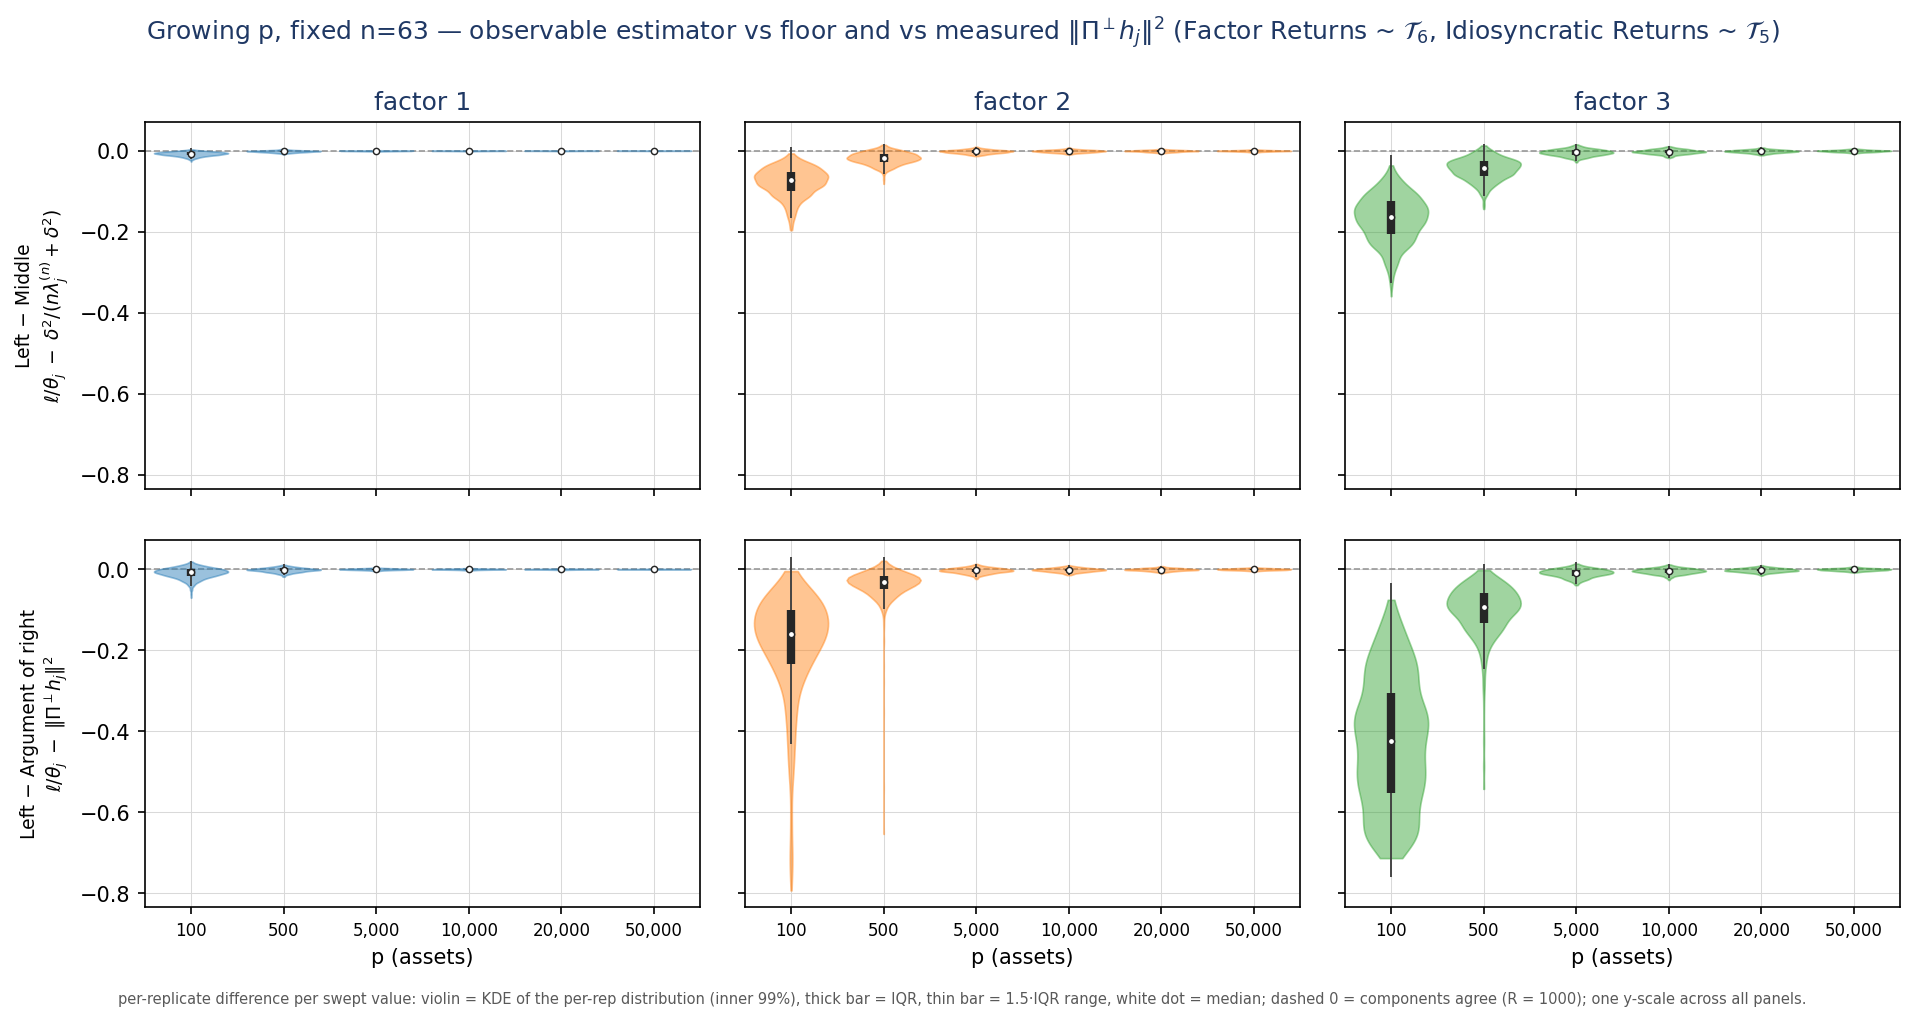

In [13]:
_v2_p_png = OUT_DIR / "ex3_pathwise_violins_2row_growing_p.png"
fig_v2_p, _ = pathwise_violin_grid_2(
    df_p, "p", out_path=str(_v2_p_png),
    suptitle=rf"Growing p, fixed n=63 — observable estimator vs floor and vs measured "
             rf"$\Vert\Pi^{{\perp}}h_j\Vert^2$ (Factor Returns ~ {_ret_lab}, "
             rf"Idiosyncratic Returns ~ {_idio_lab})")
fig_v2_p.savefig(OUT_DIR / "ex3_pathwise_violins_2row_growing_p.pdf", bbox_inches="tight")
display(Image(filename=str(_v2_p_png)))
plt.close(fig_v2_p)

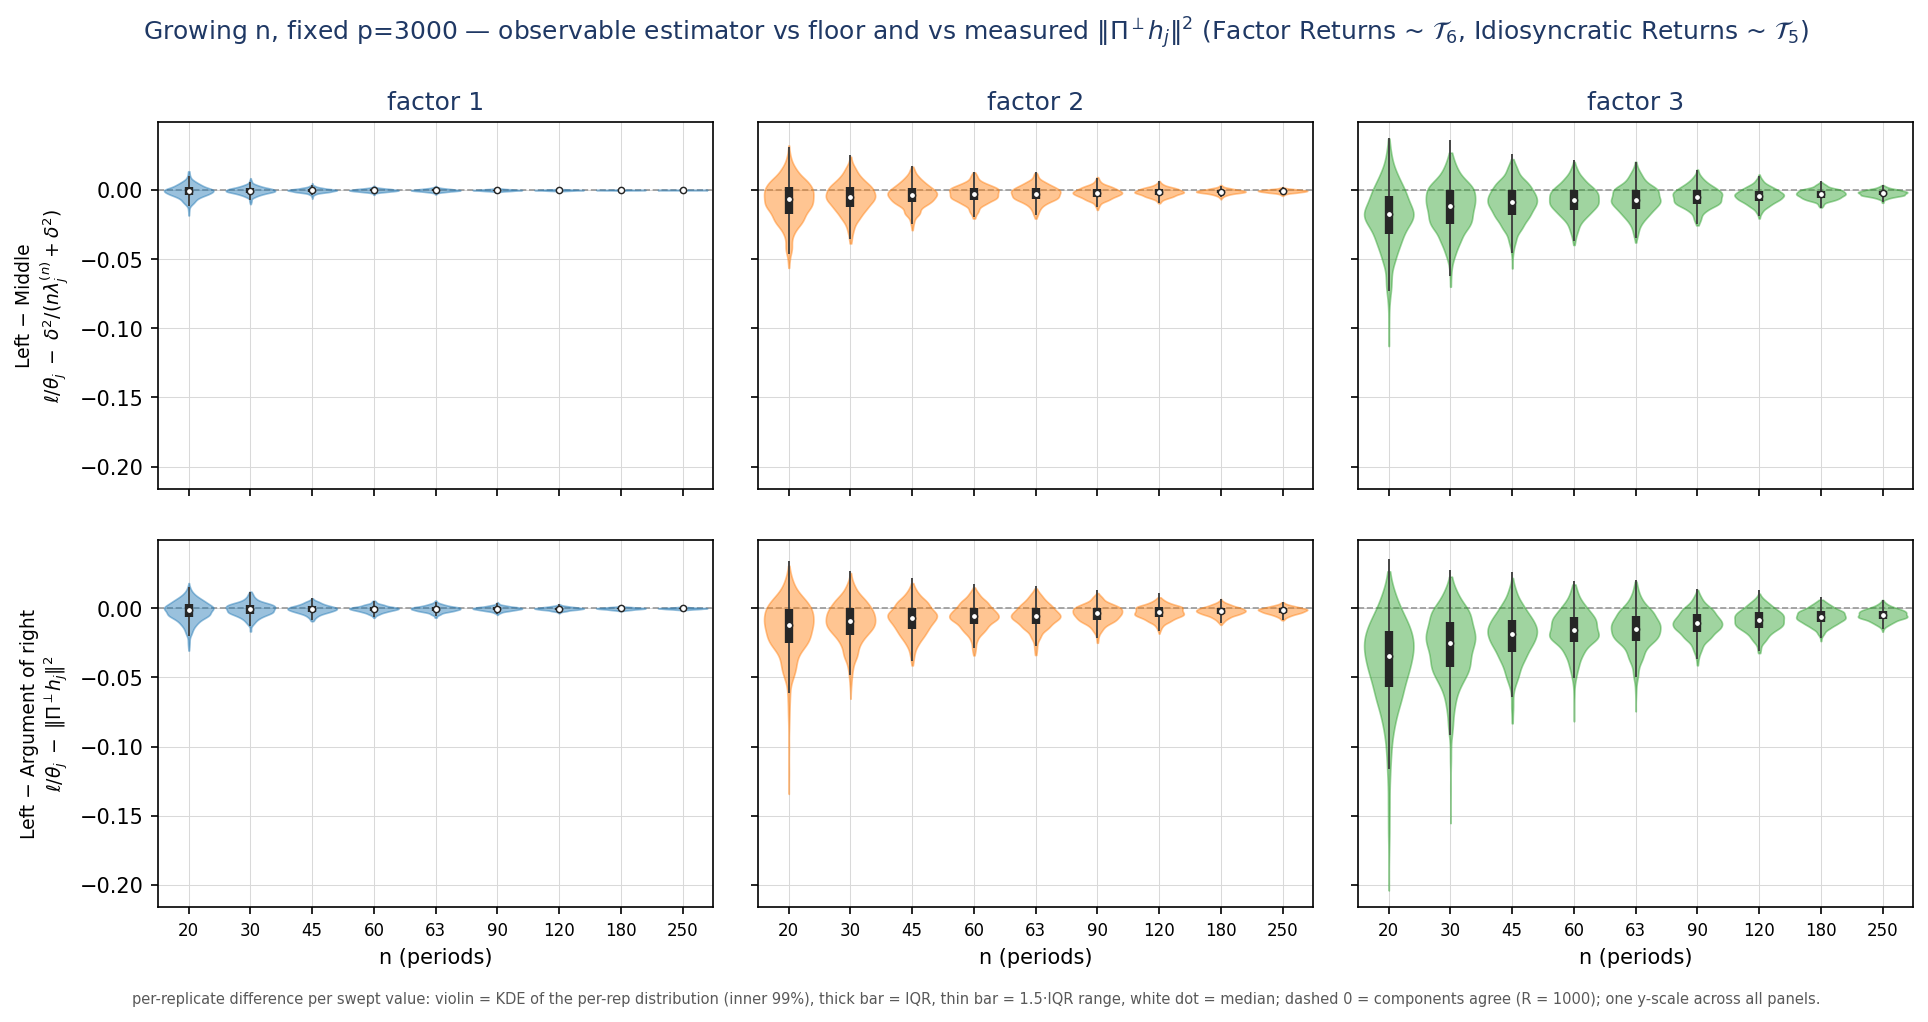

In [14]:
_v2_n_png = OUT_DIR / "ex3_pathwise_violins_2row_growing_n.png"
fig_v2_n, _ = pathwise_violin_grid_2(
    df_n, "n", out_path=str(_v2_n_png),
    suptitle=rf"Growing n, fixed p=3000 — observable estimator vs floor and vs measured "
             rf"$\Vert\Pi^{{\perp}}h_j\Vert^2$ (Factor Returns ~ {_ret_lab}, "
             rf"Idiosyncratic Returns ~ {_idio_lab})")
fig_v2_n.savefig(OUT_DIR / "ex3_pathwise_violins_2row_growing_n.pdf", bbox_inches="tight")
display(Image(filename=str(_v2_n_png)))
plt.close(fig_v2_n)

## Figures 7–8 — single-row variant (Left − Argument of right only)

The same two sweeps reduced to the one comparison of interest — the observable estimator
against the finite-$p$ measured out-of-subspace mass:

$$\ell^{(p,n)}/\theta_j^{(p,n)} \;-\; \lVert\Pi^{\perp}h_j\rVert^2$$

One panel per factor, per-replicate violins at each swept value, y shared across the three
panels. Same styling as Figures 5–6; positive means the observable estimate overshoots the
measured mass.

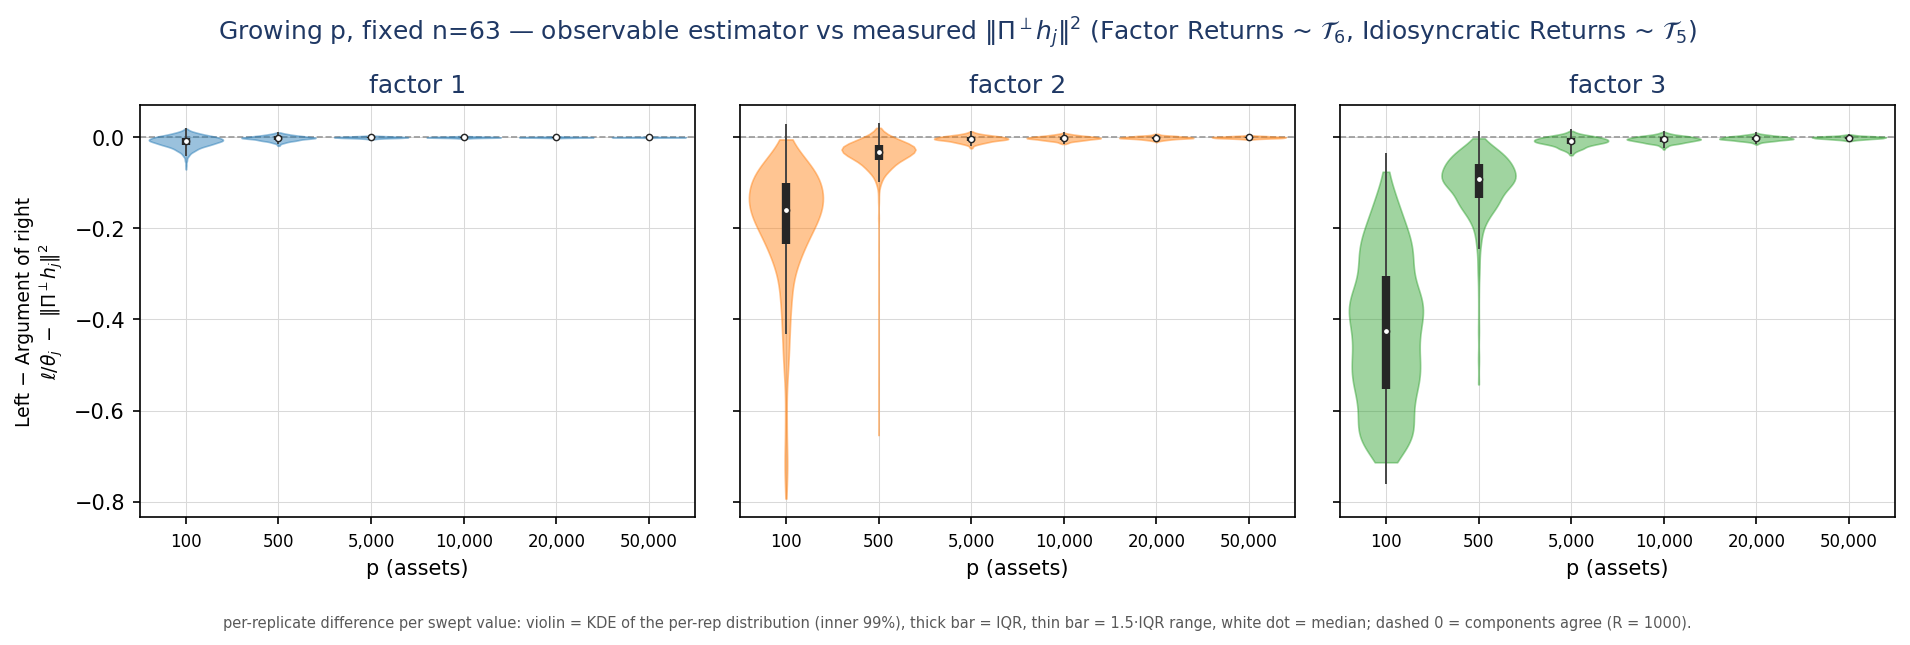

In [15]:
_DIFF_LEFT_ARG = ("diff_left_arg", "Left − Argument of right",
                  r"$\ell/\theta_j\; -\; \Vert\Pi^{\perp}h_j\Vert^2$")

def pathwise_violin_single(df, swept_key, *, suptitle=None, out_path=None):
    """1×3: only the Left − Argument-of-right difference, one panel per factor.
    Identical styling to pathwise_violin_grid_2 (same _np_gap_violin_panel, dashed 0-line,
    shared y across the three factor panels)."""
    rf = add_pathwise_differences_2(df)
    col_name, row_label, row_math = _DIFF_LEFT_ARG
    factors = [1, 2, 3]
    order = sorted(rf[swept_key].unique())
    cats = [f"{v:,}" for v in order] if swept_key == "p" else [str(v) for v in order]
    x = np.arange(len(order))
    xlabel = "p (assets)" if swept_key == "p" else "n (periods)"

    fig, axes = plt.subplots(1, 3, figsize=(13.3, 4.3), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.09, right=0.97, top=0.83, bottom=0.19, wspace=0.08)
    for col, j in enumerate(factors):
        ax = axes[col]
        sub = rf[rf["j"] == j]
        dists = [sub.loc[sub[swept_key] == v, col_name].to_numpy() for v in order]
        _np_gap_violin_panel(ax, dists, x, cats, _NP_COLORS[col])
        ax.set_axisbelow(True)
        ax.grid(True, color="0.85", lw=0.5)
        ax.set_title(f"factor {j}", color=_NP_NAVY)
        ax.set_xlabel(xlabel)
    axes[0].set_ylabel(f"{row_label}\n{row_math}", fontsize=9)
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.97)
    fig.text(0.5, 0.02,
             f"per-replicate difference per swept value: {_VIOLIN_CAP}; "
             f"dashed 0 = components agree (R = {N_REPS}).",
             ha="center", fontsize=7, color="0.35")
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes


_v1_p_png = OUT_DIR / "ex3_pathwise_violins_1row_growing_p.png"
fig_v1_p, _ = pathwise_violin_single(
    df_p, "p", out_path=str(_v1_p_png),
    suptitle=rf"Growing p, fixed n=63 — observable estimator vs measured "
             rf"$\Vert\Pi^{{\perp}}h_j\Vert^2$ (Factor Returns ~ {_ret_lab}, "
             rf"Idiosyncratic Returns ~ {_idio_lab})")
fig_v1_p.savefig(OUT_DIR / "ex3_pathwise_violins_1row_growing_p.pdf", bbox_inches="tight")
display(Image(filename=str(_v1_p_png)))
plt.close(fig_v1_p)

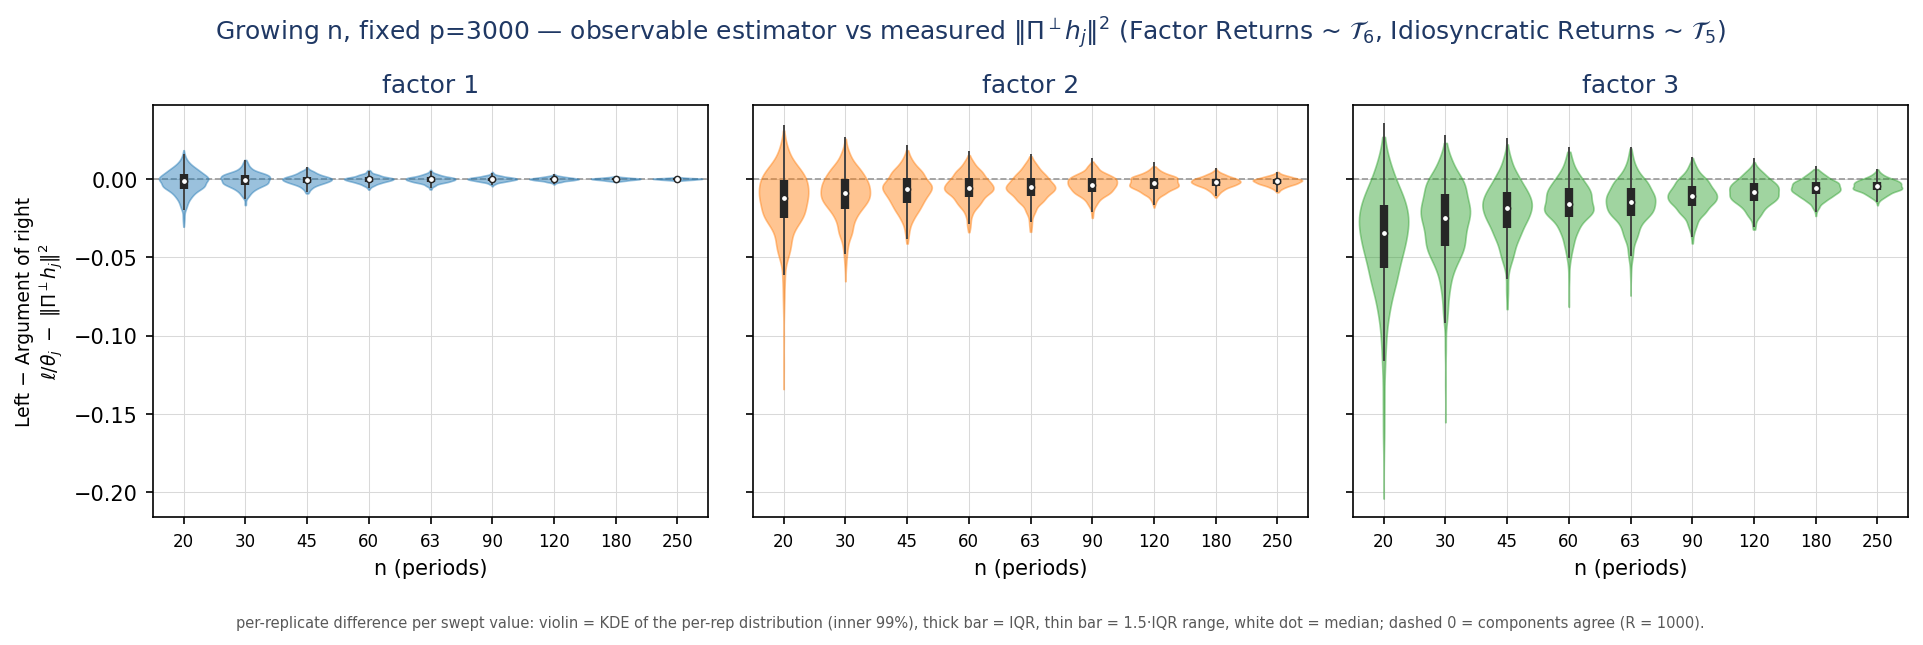

In [16]:
_v1_n_png = OUT_DIR / "ex3_pathwise_violins_1row_growing_n.png"
fig_v1_n, _ = pathwise_violin_single(
    df_n, "n", out_path=str(_v1_n_png),
    suptitle=rf"Growing n, fixed p=3000 — observable estimator vs measured "
             rf"$\Vert\Pi^{{\perp}}h_j\Vert^2$ (Factor Returns ~ {_ret_lab}, "
             rf"Idiosyncratic Returns ~ {_idio_lab})")
fig_v1_n.savefig(OUT_DIR / "ex3_pathwise_violins_1row_growing_n.pdf", bbox_inches="tight")
display(Image(filename=str(_v1_n_png)))
plt.close(fig_v1_n)

---
## Change log

- **2026-07-31**: new notebook — violin variant of `ex-3_pathwise_formula31`. All three
  pathwise views (3×3, 2×3 sign-aligned, 1×3 Left − Argument) are redrawn with
  `_np_gap_violin_panel`; sweeps, differences, tables and seeds are unchanged.
  `ex-3_pathwise_formula31.ipynb` and every `.py` file (including `fl_graphics`) are untouched.
- Sweeps are loaded from `nb_outputs/ex2v2_df_{p,n}.parquet` when present — ex-2 v2 and ex-3
  run the identical model / design / seed / experiment class — and re-run only on a mismatch.
- Violin conventions: KDE body over the inner 99% of replicates (`VIOLIN_CLIP`, so heavy tails
  do not stretch the panel the way `showfliers=False` prevented for the boxes), each violin
  normalized to a common max width, inner summary (`VIOLIN_INNER`) = 1.5·IQR line + IQR bar +
  white median dot, computed on the untrimmed sample.
- Figures write to `nb_outputs/ex-3_pathwise_formula31_violin/` (this notebook's own folder,
  PNG + PDF), so nothing collides with the ex-3 boxplot outputs; only the parquet sweep cache is
  shared, and this notebook never writes to it unless it has to run the sweeps itself.